In [1]:
suppressPackageStartupMessages({
  require(data.table)
  require(ggplot2)
  require(ggpubr)
  require(dplyr)
  library(ggnewscale)
})

subject_color_map <- c(
  "FH1001" = "#1f77b4", "FH1002" = "#ff7f0e", "FH1003" = "#279e68",
  "FH1004" = "#d62728", "FH1005" = "#aa40fc", "FH1006" = "#8c564b",
  "FH1007" = "#e377c2", "FH1008" = "#b5bd61", "FH1009" = "#17becf",
  "FH1010" = "#aec7e8", "FH1011" = "#ffbb78", "FH1012" = "#98df8a",
  "FH1014" = "#ff9896", "FH1016" = "#c5b0d5", "FH1017" = "#c49c94",
  "FH1018" = "#f7b6d2", "FH1021" = "#dbdb8d"
)

meta <- as.data.table(readxl::read_excel("../../data/figure-inputs/metadata/ndmm-rrmm-metadata-2025.xlsx", sheet = 1))
FH1 <- fread("../../data/figure-inputs/msd/flu_response_cv_classification.csv")

age_comparison <- left_join(distinct(FH1[, c("Subject", "Responder")]), distinct(meta[, c("Subject", "ageAtEnrollment")]))
age_comparison$ageAtEnrollment <- as.numeric(age_comparison$ageAtEnrollment)

Joining with `by = join_by(Subject)`


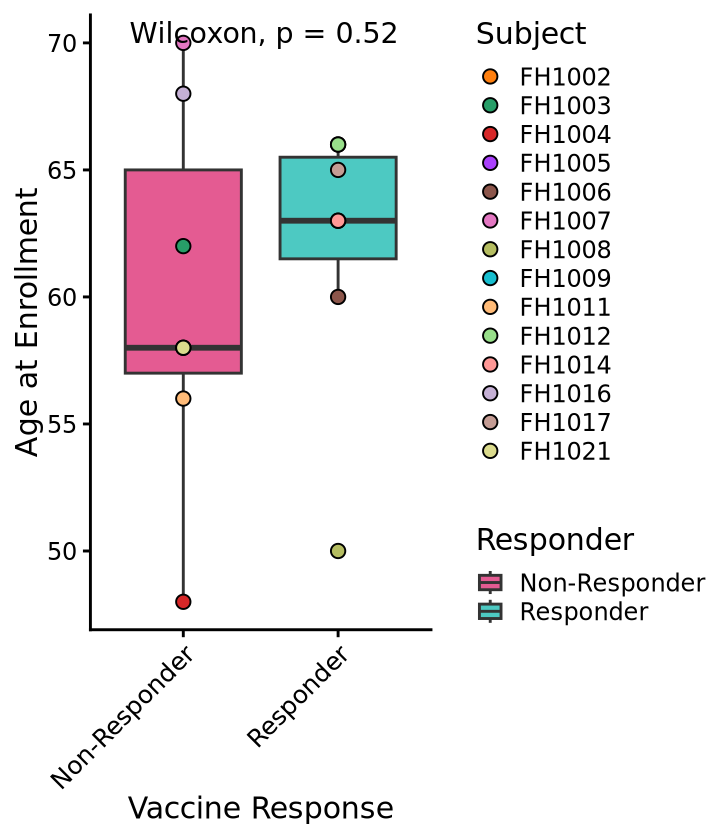

In [2]:
options(repr.plot.width = 6, repr.plot.height = 7)

p <- ggplot(age_comparison, aes(x = Responder, y = ageAtEnrollment)) +
  geom_boxplot(aes(fill = Responder), alpha = 0.7, outlier.shape = NA) +
  scale_fill_manual(values = c("Non-Responder" = "#d81463", "Responder" = "#00b2a8")) +
  new_scale_fill() +
  geom_point(aes(fill = Subject), shape = 21, size = 3.5, color = "black") +
  scale_fill_manual(values = subject_color_map) +
  ggpubr::stat_compare_means(size = 6) +
  theme_classic(base_size = 18) +
  theme(
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, size=15)
  ) +
  xlab("Vaccine Response") +
  ylab("Age at Enrollment")
p

ggsave("../../data/figure-outputs/supplementary-7/sup_7e.pdf", plot = p, width = 6, height = 7, dpi = 200, device = cairo_pdf)